In [1]:
%config IPCompleter.greedy=True

In [2]:
%pip install matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In questa esercitazione studieremo l'andamento del potenziale elettrostatico $V(x)$ e del campo elettrostatico $E(x)$ fra due piastre conduttrici poste a distanza fissa e con potenziale costante su di esse considerando diverse distribuzioni di carica.
Dovremo utilizzare l'equazione di Laplace $$\nabla^2 \phi=0$$ quando la regione di spazio studiata ha densità di carica nulla e quella di Poisson $$-\nabla^2 \phi = \frac{\rho}{\varepsilon_0}$$ in caso contrario.

Nelle varie casistiche porremo la distanza fra gli elettrodi $L$ pari a 1, così come la costante $\varepsilon_0$. Inoltre, utilizzeremo $N=50$ punti per suddividere l'intervallo tranne che nel caso della distribuzione gaussiana, in cui utilizzeremo $N=100$ per avere una migliore risoluzione delle curve.

Per quanto riguarda la risoluzione numerica delle equazioni faremo affidamento al **metodo delle differenze finite** perché siamo in presenza di problemi ai **valori al contorno**, cioè non abbiamo condizioni specificato all'inizio ma ai bordi del dominio spaziale. Con questo metodo possiamo trasformare le equazioni differenziali in un sistema di equazioni algebriche lineari.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]
pot_num_color, pot_a_color = "#e3e014", "#410969"
el_num_color, el_a_color = "#e32d19", "#5e32cf"

Per prima cosa **discretizziamo** l'intervallo spaziale in una griglia di punti equispaziati e restringiamo il dominio escludendo gli estremi, infatti in questi punti non siamo in grado di calcolare la derivata prima del potenziale.

In [21]:
L, N, rho0 = 1, 50, 1
h = L/N
x = np.linspace(0, L, N+1)
x_int = x[1:-1]

In [5]:
def sin_charge(x: float) -> tuple[float, float]:
    L, rho0, epsilon0 = 1, 1, 1
    rho = (rho0 / epsilon0) * (L / np.pi)**2 * np.sin(np.pi * x / L)
    E = -(rho0 / epsilon0) * (L / np.pi) * np.cos(np.pi * x / L)
    
    return rho, E

sin_pot_a, sin_E_a = sin_charge(x_int)

Avendo un sistema di equazioni algebriche lineari possiamo utilizzare i metodi dell'Algebra Lineare per risolverlo: $$A\phi=b,$$ con $\phi$ vettore incognito che ci restituirà le soluzioni in ogni punto del dominio. La matrice $A$ è **tridiagonale**, cioè ha elementi non nulli solo sulla diagonale principale e sulle due adiacenti, simmetrica, definita positiva e diagonalmente dominante. L'insieme di queste proprietà assicura che il sistema ammette un'unica soluzione e che quindi i metodi risolutivi convergono.

Dalla teoria dell'Elettromagnetismo sappiamo che il campo elettrico può essere espresso in funzione del potenziale elettrico: $$\vec{E}=-\vec{\nabla}V.$$ Nel nostro caso specifico siamo in una dimensione e quindi possiamo scrivere $E=-d\phi(x)/dx$ e numericamente questa derivata equivale a calcolare: $$E_{i}\approx-\frac{\phi_{i+1}-\phi_{i-1}}{2h},$$ dove stiamo utilizzando la notazione $\phi(x_{i+1})=\phi_{i+1}$.

In [7]:
def diff_sin(N: float, x: list[float], h: float, rho0: float = 1) -> float:
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = rho0 * np.sin(np.pi * x / L)
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    pot_int = np.linalg.solve(A, b)

    return pot_int

def electric_field(x_int: list[float], pot_int: list[float]) -> list[float]:
    E = np.zeros(len(x_int))
    k = -1/(2*h)
    for i in range(1, len(x_int)-1):
        E[i] = (pot_int[i+1] - pot_int[i-1]) * k
    
    E[0] = (pot_int[1] - pot_int[0]) * 2 * k
    E[-1] = (pot_int[-1] - pot_int[-2]) * 2 * k

    return E
    
pot_int = diff_sin(N=50, x=x_int, h=h)
E = electric_field(x_int=x_int, pot_int=pot_int)

In [8]:
print(max(abs(pot_int - sin_charge(x_int)[0])))
print(max(abs(E-sin_E_a)))

3.3339914100094514e-05
0.0007324251872328214


Notiamo che gli errori del metodo rispetto alla soluzione analitica sono molto piccoli. Per una distribuzione di carica sinusoidale con potenziale nullo ai bordi otteniamo: $$\epsilon_{\phi}=|\phi_{th}-\phi_{num}|=3.33\times10^{-5}\ V,$$ $$\epsilon_{E}=|E_{th}-E_{num}|=7\times10^{-4}\ V/m.$$

In [9]:
Ns = np.array([10, 20, 40, 80, 160])
hs = L / Ns
errs = []

for i in range(len(Ns)):
    xs = np.linspace(0, L, Ns[i]+1)
    xs_int = xs[1:-1]
    pot_a, _ = sin_charge(xs_int)
    pot_n = diff_sin(N=Ns[i], x=xs_int, h=hs[i])
    errs.append(np.max(np.abs(pot_a - pot_n)))

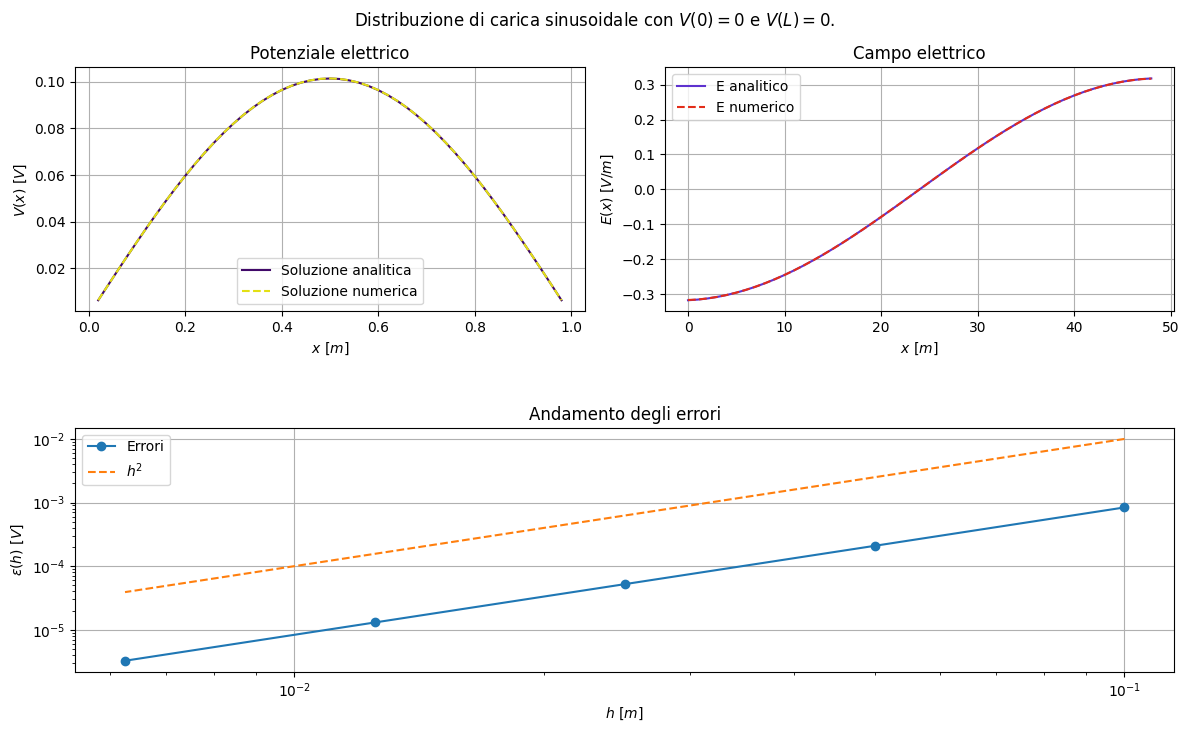

In [43]:
fig, axd = plt.subplot_mosaic([['ax1', 'ax2'], ['ax3', 'ax3']])
ax1, ax2, ax3 = axd["ax1"], axd["ax2"], axd["ax3"]

ax1.plot(x_int, sin_pot_a, color=pot_a_color, label="Soluzione analitica")
ax1.plot(x_int, pot_int, "--", color=pot_num_color, label="Soluzione numerica")
ax1.grid(True)
ax1.set_xlabel(r"$x\ [m]$")
ax1.set_ylabel(r"$V(x)\ [V]$")
ax1.set_title("Potenziale elettrico")
ax1.legend()

ax2.plot(sin_E_a, color=el_a_color, label="E analitico")
ax2.plot(E, "--", color=el_num_color, label="E numerico")
ax2.legend()
ax2.grid(True)
ax2.set_xlabel(r"$x\ [m]$")
ax2.set_ylabel(r"$E(x)\ [V/m]$")
ax2.set_title("Campo elettrico")

ax3.loglog(hs, errs, "-o", label="Errori")
ax3.plot(hs, hs**2, "--", label=r"$h^2$")
ax3.grid()
ax3.legend()
ax3.set_title("Andamento degli errori")
ax3.set_xlabel(r"$h\ [m]$")
ax3.set_ylabel(r"$\varepsilon(h)\ [V]$")

plt.suptitle(r"Distribuzione di carica sinusoidale con $V(0)=0$ e $V(L)=0$.")
plt.tight_layout(h_pad=3.5)
plt.show()

Consideriamo ora il caso di una densità di carica costante, cioè abbiamo che la regione fra i due elettrodi è uniformemente carica. I due elettrodi sono sempre a potenziale nullo e quindi il massimo del potenziale si trova al centro della regione. Questo è anche il punto in cui il campo elettrico si annulla: questa osservazione si può ricavare facilmente da considerazioni analitiche, infatti nei massimi di una funzione otteniamo derivata prima nulla.

In [24]:
def cost_charge(x: float) -> float:
    L, rho0, epsilon0 = 1, 1, 1
    pot = (rho0 / (2 * epsilon0)) * x * (L - x)
    
    return pot
    
def diff_cost(N: float, x: list[float], h: float, rho0: float = 1) -> float:
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = np.ones(len(x)) * rho0
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    pot_int = np.linalg.solve(A, b)

    return pot_int

def electric_field(x_int: list[float], pot_int: list[float]) -> list[float]:
    E = np.zeros(len(x_int))
    k = -1/(2*h)
    for i in range(1, len(x_int)-1):
        E[i] = (pot_int[i+1] - pot_int[i-1]) * k
    
    E[0] = (pot_int[1] - pot_int[0]) * 2 * k
    E[-1] = (pot_int[-1] - pot_int[-2]) * 2 * k

    return E

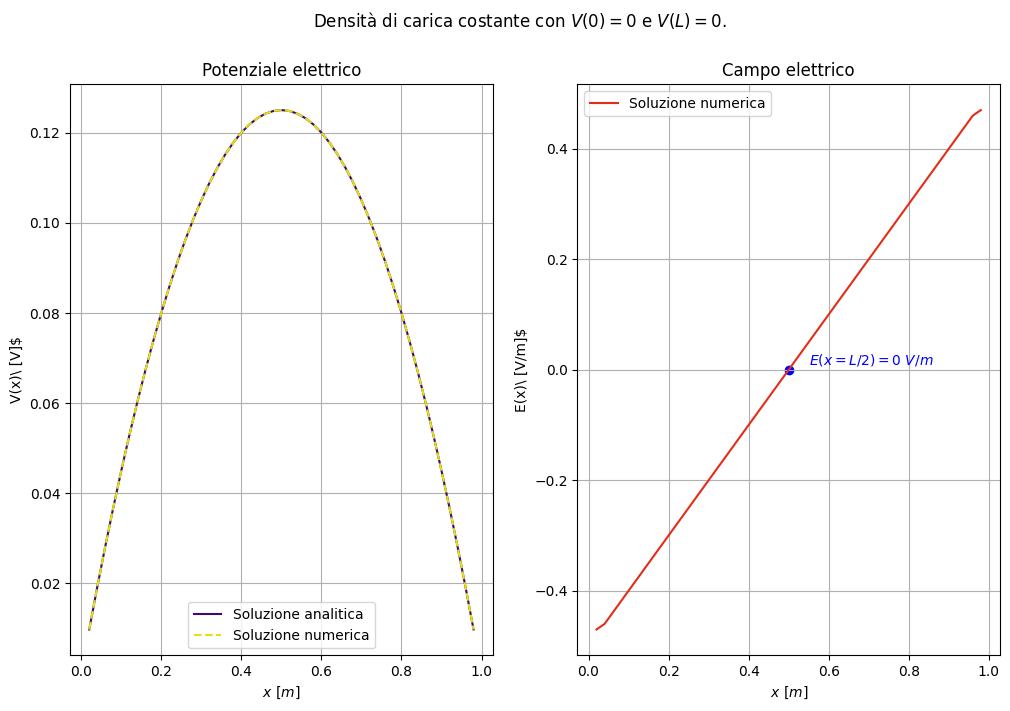

In [48]:
cost_pot = cost_charge(x=x_int)
cost_pot_num = diff_cost(N=50, x=x_int, h=h)
cost_E_num = electric_field(x_int=x_int, pot_int=cost_pot_num)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(x_int, cost_pot, color=pot_a_color, label="Soluzione analitica")
ax1.plot(x_int, cost_pot_num, "--", color=pot_num_color, label="Soluzione numerica")
ax1.grid(True)
ax1.set_xlabel(r"$x\ [m]$")
ax1.set_ylabel(r"V(x)\ [V]$")
ax1.legend()
ax1.set_title("Potenziale elettrico")


ax2.plot(x_int, cost_E_num, color=el_num_color, label="Soluzione numerica")
ax2.scatter(L/2, 0, color="blue",)
ax2.text(0.55, 0.01, s=r"$E(x=L/2)=0\ V/m$", color="blue", fontweight="bold")
ax2.grid(True)
ax2.set_xlabel(r"$x\ [m]$")
ax2.set_ylabel(r"E(x)\ [V/m]$")
ax2.legend()
ax2.set_title("Campo elettrico")

plt.suptitle(r"Densità di carica costante con $V(0)=0$ e $V(L)=0$.")
plt.show()

Possiamo ora considerare il caso classico di un condensatore piano vuoto e utilizzare l'equazione di Laplace per risolvere questo problema. Poniamo i due elettrodi a potenziale diverso, in particolare $\phi(0)=0\ V$ e $\phi(L)=10\ V$. Ci aspettiamo un campo elettrico costante e inversamente proporzionale alla distanza fra le armature: $$V=Eh \iff E=\frac{V}{h}.$$

Dalla simulazione otteniamo un ottimo riscontro con la teoria: il campo elettrico ha un valore costante pari a $-10\ V/m$ e infatti la differenza di potenziale fra le armature è $\phi(L)-\phi(0)=10\ V$ e la distanza fra esse è $L=1\ m$.

In [28]:
def cond_piano(x: float):
    L = 1
    Va, Vb = 0, 10
    
    return Va + (Vb - Va) * x / L

def diff_cond_piano(N: float, x: list[float], h: float, rho0: float = 0) -> float:
    Va, Vb = 0, 10
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = x * rho0
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    pot_int = np.linalg.solve(A, b)

    return pot_int


diff_cond_p = diff_cond_piano(N=50, x=x_int, h=h)
E_cond_piano = electric_field(x_int=x_int, pot_int=diff_cond_p)

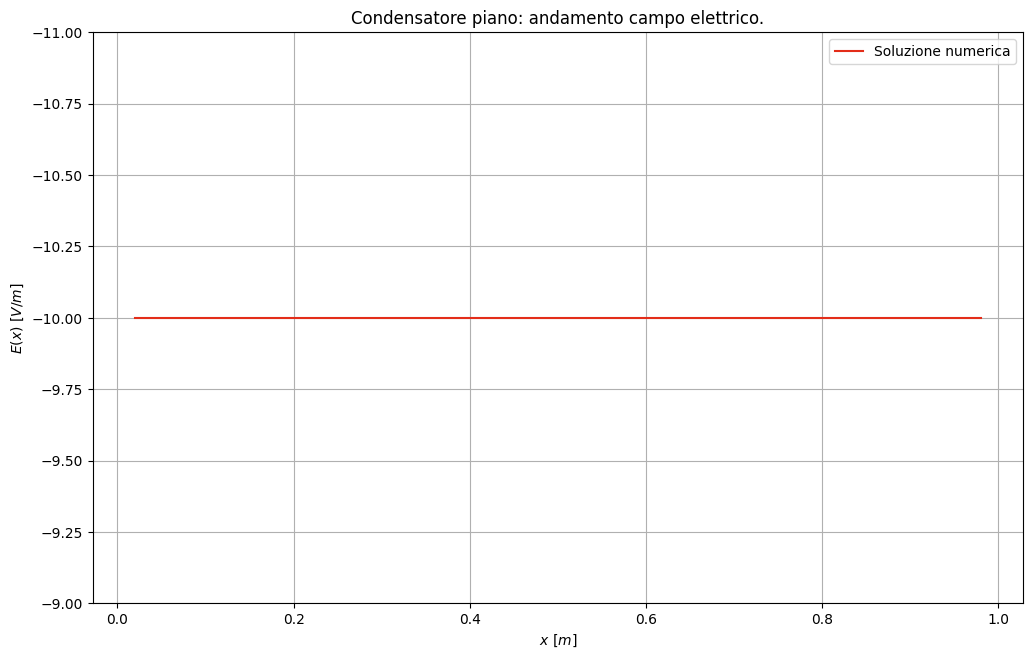

In [63]:
plt.plot(x_int, E_cond_piano, color=el_num_color, label="Soluzione numerica")
plt.grid()
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$E(x)\ [V/m]$")
plt.ylim(-9, -11)
plt.legend()
plt.title("Condensatore piano: andamento campo elettrico.")
plt.show()

Come ultimo caso consideriamo una carica localizzata al centro della regione con distribuzione gaussiana: $$\rho(x)=\rho_{0} \exp\left(-\frac{(x-\frac{L}{2})^2}{2\sigma^2}\right).$$ Imponiamo sempre potenziale nullo ai bordi, $\phi(0)=\phi(L)=0$. Come nel caso precedente otteniamo che al centro della regione, cioè in corrispondenza della localizzazione della carica, si trova sia il massimo del potenziale elettrico che l'annullamento del campo elettrico. Allontanandosi dal centro si ha che la pendenza del potenziale è massima e quindi il campo elettrico cresce molto velocemente. Infine, quando la carica elettrica è approssimativamente nulla si ha che il campo elettrico è massimo e rimane costante fino ai condensatori. Questo comportamento si nota nella simulazione: in prossimità di $x=0.2\ m$ e $x=0.8\ m$ si ha che la carica è quasi nulla e il campo elettrico rimane costante e pari al suo valore massimo in valore assoluto.

In [65]:
L1, sigma, N1 = 1, 0.1, 100
x1 = np.linspace(0, L1, N1+1)
x1_int = x1[1:-1]
h1 = L1/N1

def diff_gauss(N: int, x: list[float], h: float, L: int, sigma: float, rho0: float = 1):
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = rho0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    pot_int = np.linalg.solve(A, b)

    return pot_int, b

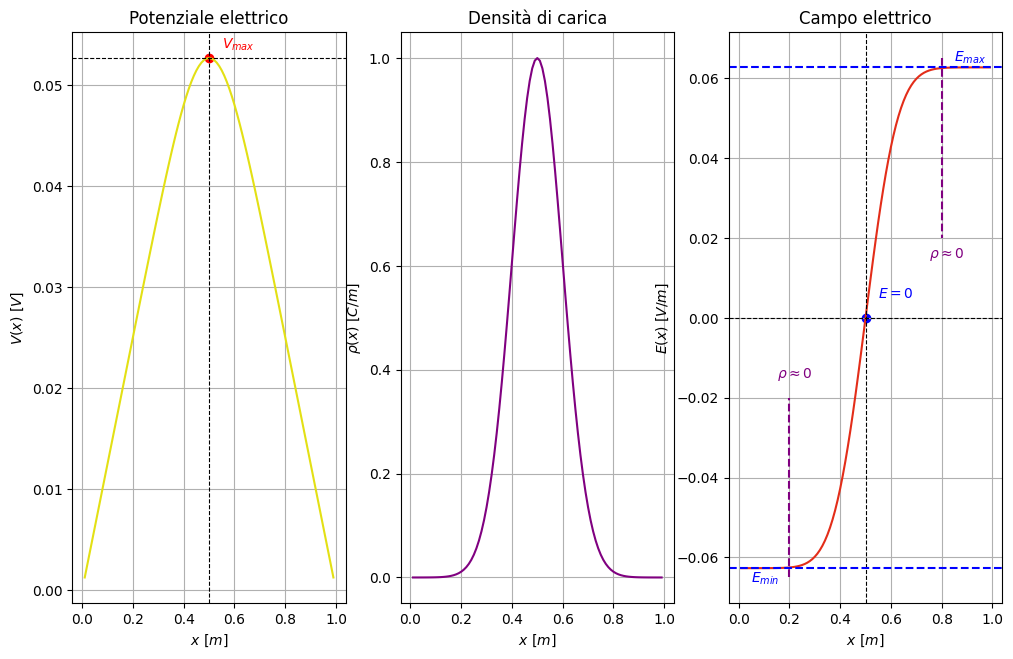

In [87]:
phi_gauss, rho_gauss = diff_gauss(N=N1, x=x1_int, h=h1, L=L1, sigma=sigma)
e_gauss = electric_field(x1_int, phi_gauss)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

ax1.plot(x1_int, phi_gauss, color=pot_num_color)
ax1.axvline(L/2, ls="--", lw=0.8, color="black")
ax1.axhline(np.max(phi_gauss), ls="--", lw=0.8, color="black")
ax1.set_xlabel(r"$x\ [m]$")
ax1.set_ylabel(r"$V(x)\ [V]$")
ax1.grid(True)
ax1.set_title("Potenziale elettrico")
ax1.scatter(L1/2, np.max(phi_gauss), color="red")
ax1.text(L1/2 + 0.05, np.max(phi_gauss)+0.001, s=r"$V_{max}$", color="red", fontweight="bold")

ax2.plot(x1_int, rho_gauss, color="purple")
ax2.set_xlabel(r"$x\ [m]$")
ax2.set_ylabel(r"$\rho(x)\ [C/m]$")
ax2.grid(True)
ax2.set_title("Densità di carica")

ax3.plot(x1_int, e_gauss, color=el_num_color)
ax3.axvline(L/2, ls="--", lw=0.8, color="black")
ax3.axhline(0, ls="--", lw=0.8, color="black")
ax3.axhline(np.min(e_gauss), ls="--", color="blue")
ax3.axhline(np.max(e_gauss), ls="--", color="blue")
ax3.plot([0.2, 0.2], [-0.065, -0.02], "--", color="purple")
ax3.text(0.15, -0.015, s=r"$\rho\approx0$", color="purple", fontweight="bold")
ax3.plot([0.8, 0.8], [0.065, 0.02], "--", color="purple")
ax3.text(0.75, 0.015, s=r"$\rho\approx0$", color="purple", fontweight="bold")
ax3.scatter(L/2, 0, color="blue")
ax3.text(0.55, 0.005, s=r"$E=0$", color="blue", fontweight="bold")
ax3.text(0.85, np.max(e_gauss)+0.0015, s=r"$E_{max}$", color="blue", fontweight="bold")
ax3.text(0.05, np.min(e_gauss)-0.0035, s=r"$E_{min}$", color="blue", fontweight="bold")
ax3.set_xlabel(r"$x\ [m]$")
ax3.set_ylabel(r"$E(x)\ [V/m]$")
ax3.grid(True)
ax3.set_title("Campo elettrico")

#fig.tight_layout(w_pad=2.0)
plt.show()